## 0. Imports & path setup

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from src.gradient_boosting_price import PriceClassifier

## 1. Load data

In [3]:
df = pd.read_csv("../data/raw data/best sellin books total.csv")
df.columns = df.columns.str.strip()
print(f'Shape: {df.shape}')
df.head()

Shape: (210, 13)


,Book name,Author,Rating,reviews count,form,price range,Reading age,Print Length,Publishing date,Genre,id_2023,id_2024,id_2025
0,Atomic Habits: An Easy & Proven Way to Build G...,James Clear,4.8 out of 5 stars,145747,Hardcover,$15–$25,for all,320,16/10/2018,Self-Improvement,#1,#3,#6
1,"Iron Flame (Standard Edition) (The Empyrean, 2)",Rebecca Yarros,4.7 out of 5 stars,395512,Hardcover,$5–$15,adult,640,7/11/2023,Fiction & Action & Adventure,#2,#13,NaN
2,Spare,Prince Harry The Duke of Sussex,4.5 out of 5 stars,116101,Hardcover,$5–$15,for all,416,10-Jan-23,Biographies & Memoirs,#3,NaN,NaN
3,Fourth Wing,Rebecca Yarros,4.8 out of 5 stars,472618,Paperback,$5–$15,adult,544,17/09/2024,Fiction & Action & Adventure,#4,#16,#76
4,The Woman in Me,Britney Spears,4.4 out of 5 stars,51520,Hardcover,$5–$15,adult,288,24-Oct-23,Biographies & Memoirs,#5,NaN,NaN


## 2. Explore the target

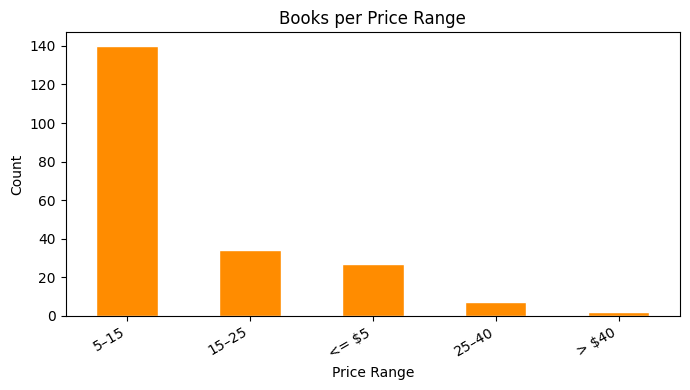

price range
$5–$15     140
$15–$25     34
<= $5       27
$25–$40      7
> $40        2
Name: count, dtype: int64


In [4]:
price_counts = df['price range'].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
price_counts.plot(kind='bar', ax=ax, color='darkorange', edgecolor='white')
ax.set_title('Books per Price Range')
ax.set_ylabel('Count')
ax.set_xlabel('Price Range')
plt.xticks(rotation=30, ha='right')
fig.tight_layout()
plt.show()
print(price_counts)

## 3. Train the model

In [5]:
clf = PriceClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    test_size=0.2,
    random_state=42,
)

clf.fit(df)
print('Training complete.')

Training complete.


## 4. Evaluate

In [6]:
results = clf.evaluate()

c:\Users\emmad\anaconda3\envs\myenv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


  GRADIENT BOOSTING — PRICE RANGE CLASSIFICATION
  Test Accuracy  : 0.6905
  5-Fold CV Acc  : 0.6810 ± 0.0243

              precision    recall  f1-score   support

     $15–$25       0.25      0.14      0.18         7
     $25–$40       0.00      0.00      0.00         1
      $5–$15       0.74      0.89      0.81        28
       <= $5       1.00      0.50      0.67         6

    accuracy                           0.69        42
   macro avg       0.50      0.38      0.41        42
weighted avg       0.67      0.69      0.66        42



## 5. Feature importance

Saved: gb_price_feature_importance.png


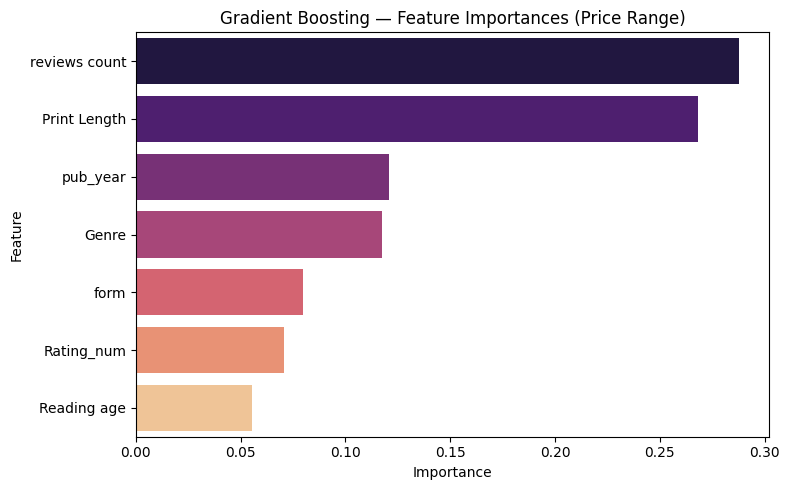

In [7]:
clf.plot_feature_importance(save_path='gb_price_feature_importance.png')

## 6. Confusion matrix

Saved: gb_price_confusion_matrix.png


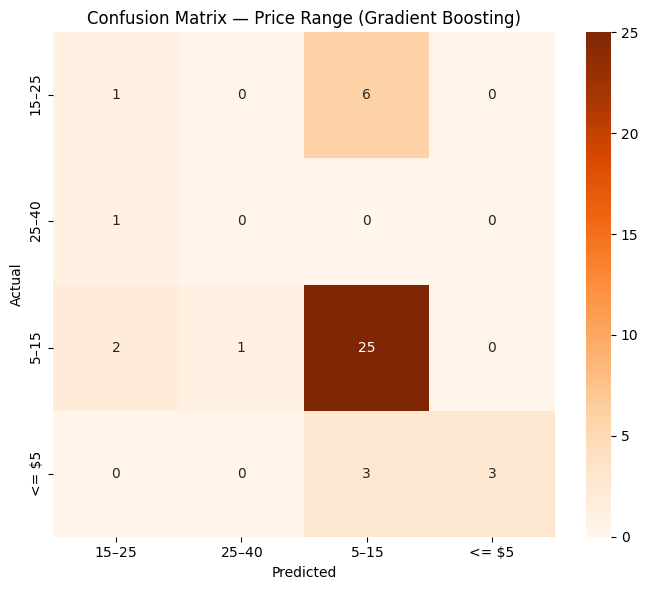

In [8]:
clf.plot_confusion_matrix(save_path='gb_price_confusion_matrix.png')

## 7. Learning curve

Saved: gb_price_learning_curve.png


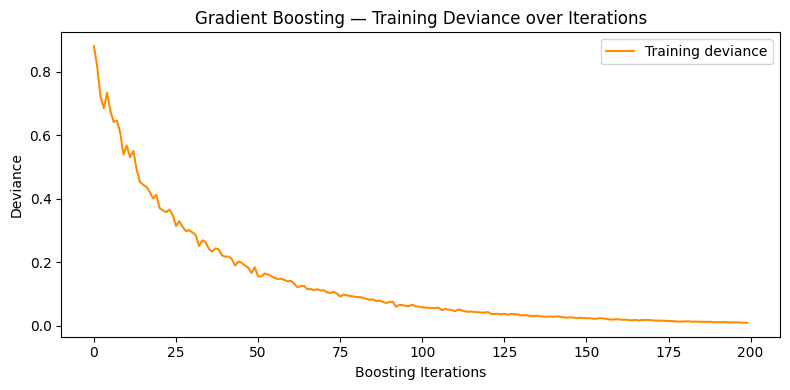

In [11]:
clf.plot_learning_curve(save_path='gb_price_learning_curve.png')